In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.datasets import load_diabetes
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.tree import plot_tree, export_graphviz
import dtreeviz
import graphviz.backend as be
import matplotlib.pyplot as plt
from IPython.display import Image, display_svg, SVG

In [40]:
X_df, y_df = load_diabetes(as_frame=True, return_X_y=True, scaled=False)

In [41]:
sample = X_df.sample(10)
idx = sample.index
sample

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
14,61.0,1.0,24.0,91.0,202.0,115.4,72.0,3.0,4.2905,73.0
405,62.0,2.0,37.8,119.0,113.0,51.0,31.0,4.0,5.0434,84.0
266,34.0,2.0,20.6,98.0,183.0,92.0,83.0,2.0,3.6889,92.0
129,51.0,1.0,27.9,96.0,196.0,122.2,42.0,5.0,5.0689,120.0
92,43.0,1.0,26.8,123.0,193.0,102.2,67.0,3.0,4.7791,94.0
184,53.0,1.0,28.6,88.0,171.0,98.8,41.0,4.0,5.0499,99.0
173,31.0,2.0,19.0,93.0,137.0,73.0,47.0,3.0,4.4427,78.0
323,68.0,2.0,25.7,109.0,233.0,112.6,35.0,7.0,6.0568,105.0
342,64.0,2.0,28.4,111.0,184.0,127.0,41.0,4.0,4.3820,97.0
391,42.0,1.0,19.9,76.0,146.0,83.2,55.0,3.0,3.6636,79.0


In [42]:
y_df[idx]

14     118.0
405    281.0
266     45.0
129    268.0
92      48.0
184    265.0
173    101.0
323    248.0
342    178.0
391     63.0
Name: target, dtype: float64

In [43]:
X_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [44]:
X_train, X_test, y_train, y_test = train_test_split(X_df.to_numpy(), y_df.to_numpy(), test_size=0.3)

In [45]:
X_train.shape

(309, 10)

In [46]:
pipe = Pipeline(
    [
        ('scaler_age_fare', StandardScaler()),
        ('model', DecisionTreeRegressor(min_samples_split=20))
    ]
)

In [47]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler_age_fare', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_spl

[Text(0.6060606060606061, 0.95, 'x[8] <= -0.062\nsquared_error = 5867.836\nsamples = 309\nvalue = 154.168'), Text(0.3939393939393939, 0.85, 'x[2] <= 0.116\nsquared_error = 2770.174\nsamples = 154\nvalue = 109.909'), Text(0.5, 0.8999999999999999, 'True  '), Text(0.2727272727272727, 0.75, 'x[6] <= 0.427\nsquared_error = 2240.415\nsamples = 122\nvalue = 100.246'), Text(0.15151515151515152, 0.65, 'x[5] <= 0.526\nsquared_error = 2847.046\nsamples = 62\nvalue = 115.226'), Text(0.12121212121212122, 0.55, 'x[1] <= 0.049\nsquared_error = 2511.697\nsamples = 54\nvalue = 108.315'), Text(0.06060606060606061, 0.45, 'x[3] <= -0.732\nsquared_error = 2688.938\nsamples = 24\nvalue = 127.25'), Text(0.030303030303030304, 0.35, 'squared_error = 2700.485\nsamples = 13\nvalue = 105.769'), Text(0.09090909090909091, 0.35, 'squared_error = 1485.504\nsamples = 11\nvalue = 152.636'), Text(0.18181818181818182, 0.45, 'x[0] <= 1.561\nsquared_error = 1853.606\nsamples = 30\nvalue = 93.167'), Text(0.15151515151515152

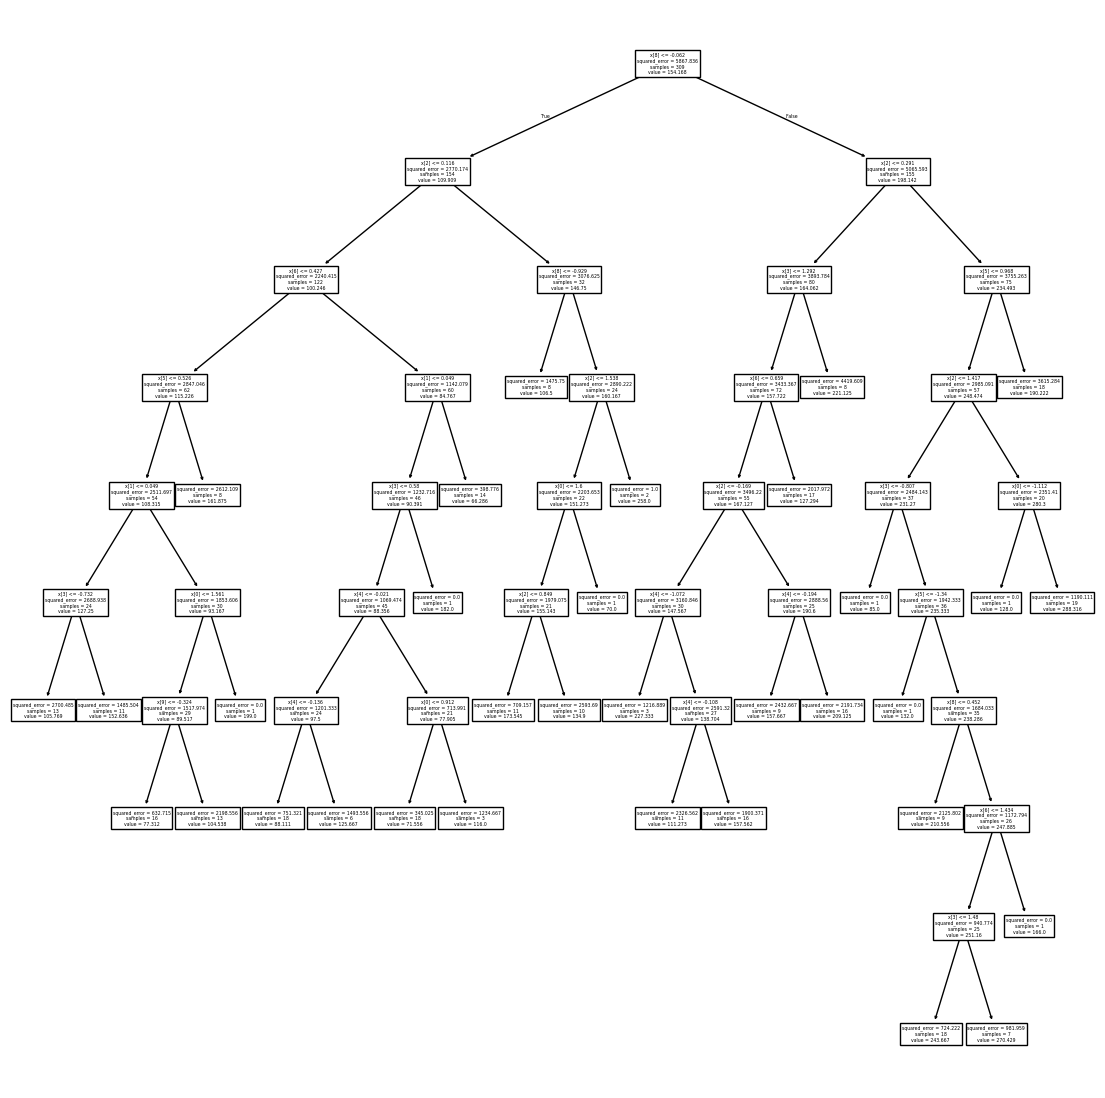

In [49]:
plt.figure(figsize=(14, 14))
print(plot_tree(pipe['model']))

In [50]:
viz_model = dtreeviz.model(pipe['model'], X_train=X_train, y_train=y_train, feature_names=X_df.columns, target_name='breast_cancer', class_names=["0", "1"])

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

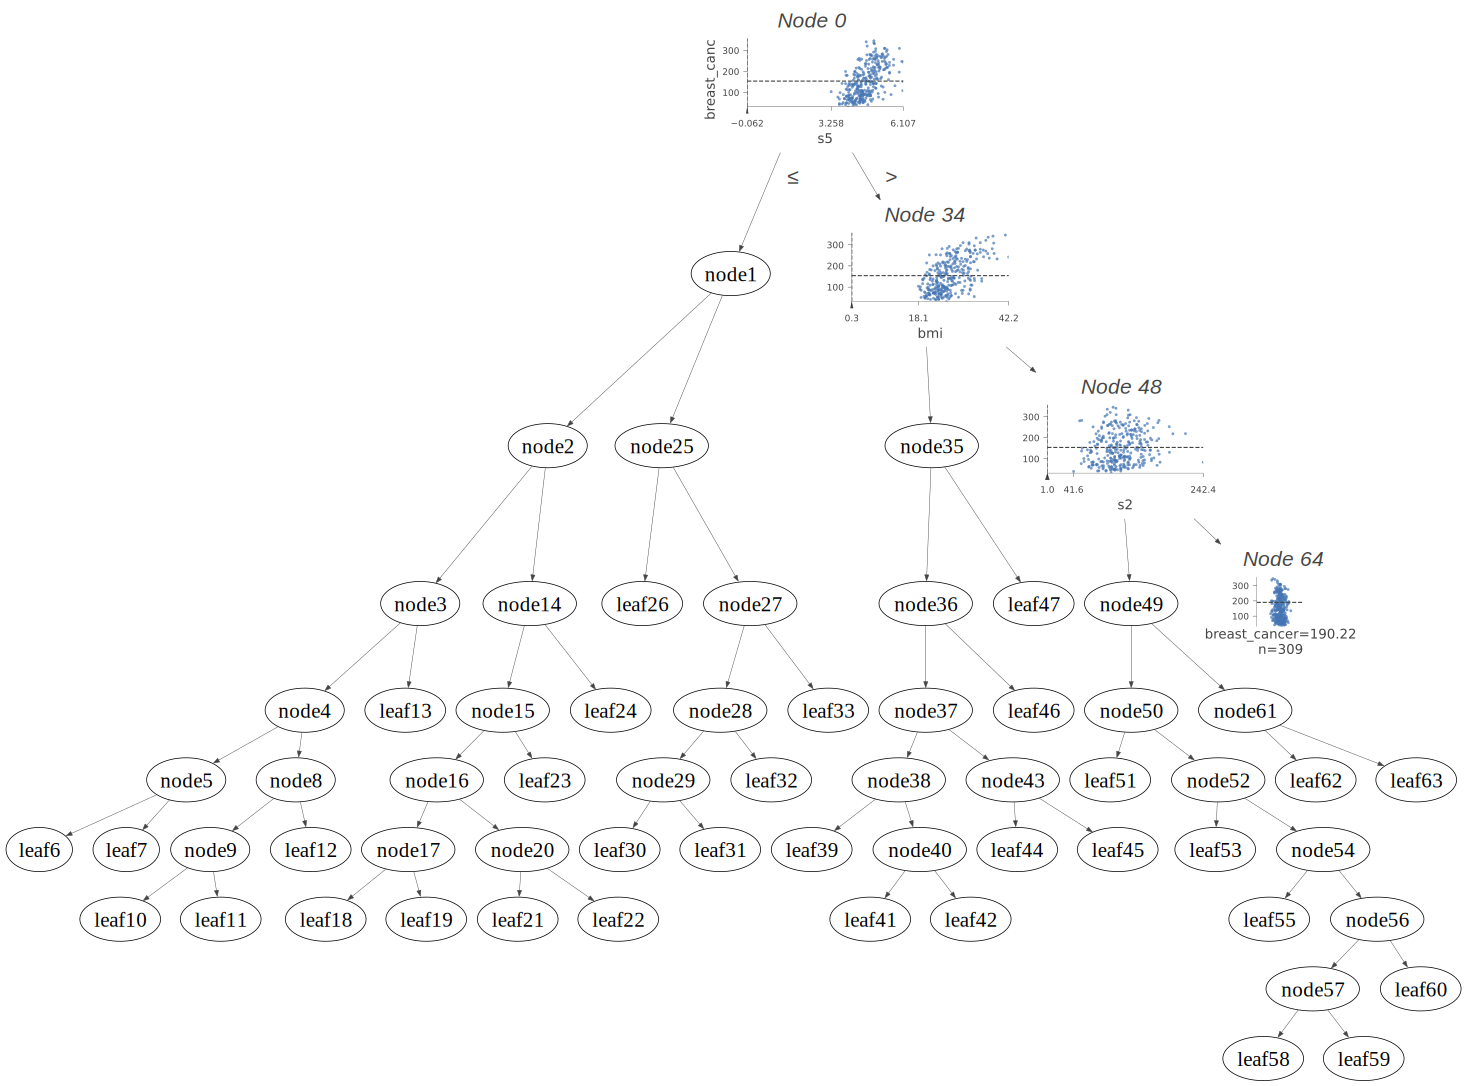

In [51]:
viz_model.view(scale=1.5, fontname='Arial', fancy=True, show_node_labels=True)

In [48]:
print("Cross val recall on  train: ", np.mean(cross_val_score(pipe, X_train, y_train, cv=10, scoring='r2')))
print("Cross val std deviation on train: ", cross_val_score(pipe, X_train, y_train, cv=10).std())

y_pred = pipe.predict(X=X_test)

print("RMSE of Test:", root_mean_squared_error(y_test, y_pred))
print("R2 of Test:", r2_score(y_test, y_pred))

Cross val recall on  train:  0.16502652041666682
Cross val std deviation on train:  0.2864854410240886
RMSE of Test: 68.43068053109164
R2 of Test: 0.22497528512512255


Hyperparam Tuning

In [52]:
high = int(X_train.shape[0] * 0.1)
if high < 2:
    high = 3
param = {
    'model__criterion' : ['squared_error', 'friedman_mse', 'poisson', 'absolute_error'],
    'model__splitter': ['best', 'random'],
    'model__max_depth': [i for i in range(1, 50)],
    #'model__min_samples_split': [i for i in range(2, high)]
}

In [53]:
grid = GridSearchCV(pipe, param_grid=param, cv=5, scoring='r2')

In [54]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...s_split=20))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['squared_error', 'friedman_mse', ...], 'model__max_depth': [1, 2, ...], 'model__splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

In [55]:
print('Grid Best R2 Score', grid.best_score_)
print('Grid Best Parameters', grid.best_params_)

Grid Best R2 Score 0.4045604372786741
Grid Best Parameters {'model__criterion': 'squared_error', 'model__max_depth': 4, 'model__splitter': 'random'}


In [56]:
y_pred = grid.predict(X_test)
print("RMSE of Test after GridSearchCV", root_mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

RMSE of Test after GridSearchCV 60.9887705039281
0.3843787665929933


In [57]:
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler_age_fare', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'random'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_spli

[Text(0.5416666666666666, 0.9, 'x[2] <= 0.297\nsquared_error = 5867.836\nsamples = 309\nvalue = 154.168'), Text(0.3611111111111111, 0.7, 'x[7] <= 0.896\nsquared_error = 3845.825\nsamples = 207\nvalue = 126.488'), Text(0.45138888888888884, 0.8, 'True  '), Text(0.2222222222222222, 0.5, 'x[7] <= 0.516\nsquared_error = 3354.329\nsamples = 186\nvalue = 119.253'), Text(0.1111111111111111, 0.3, 'x[8] <= 0.742\nsquared_error = 3154.967\nsamples = 157\nvalue = 112.962'), Text(0.05555555555555555, 0.1, 'squared_error = 2892.737\nsamples = 149\nvalue = 110.121'), Text(0.16666666666666666, 0.1, 'squared_error = 5088.859\nsamples = 8\nvalue = 165.875'), Text(0.3333333333333333, 0.3, 'x[4] <= -0.724\nsquared_error = 3059.455\nsamples = 29\nvalue = 153.31'), Text(0.2777777777777778, 0.1, 'squared_error = 153.556\nsamples = 3\nvalue = 74.333'), Text(0.3888888888888889, 0.1, 'squared_error = 2592.013\nsamples = 26\nvalue = 162.423'), Text(0.5, 0.5, 'x[6] <= -0.707\nsquared_error = 3628.721\nsamples = 2

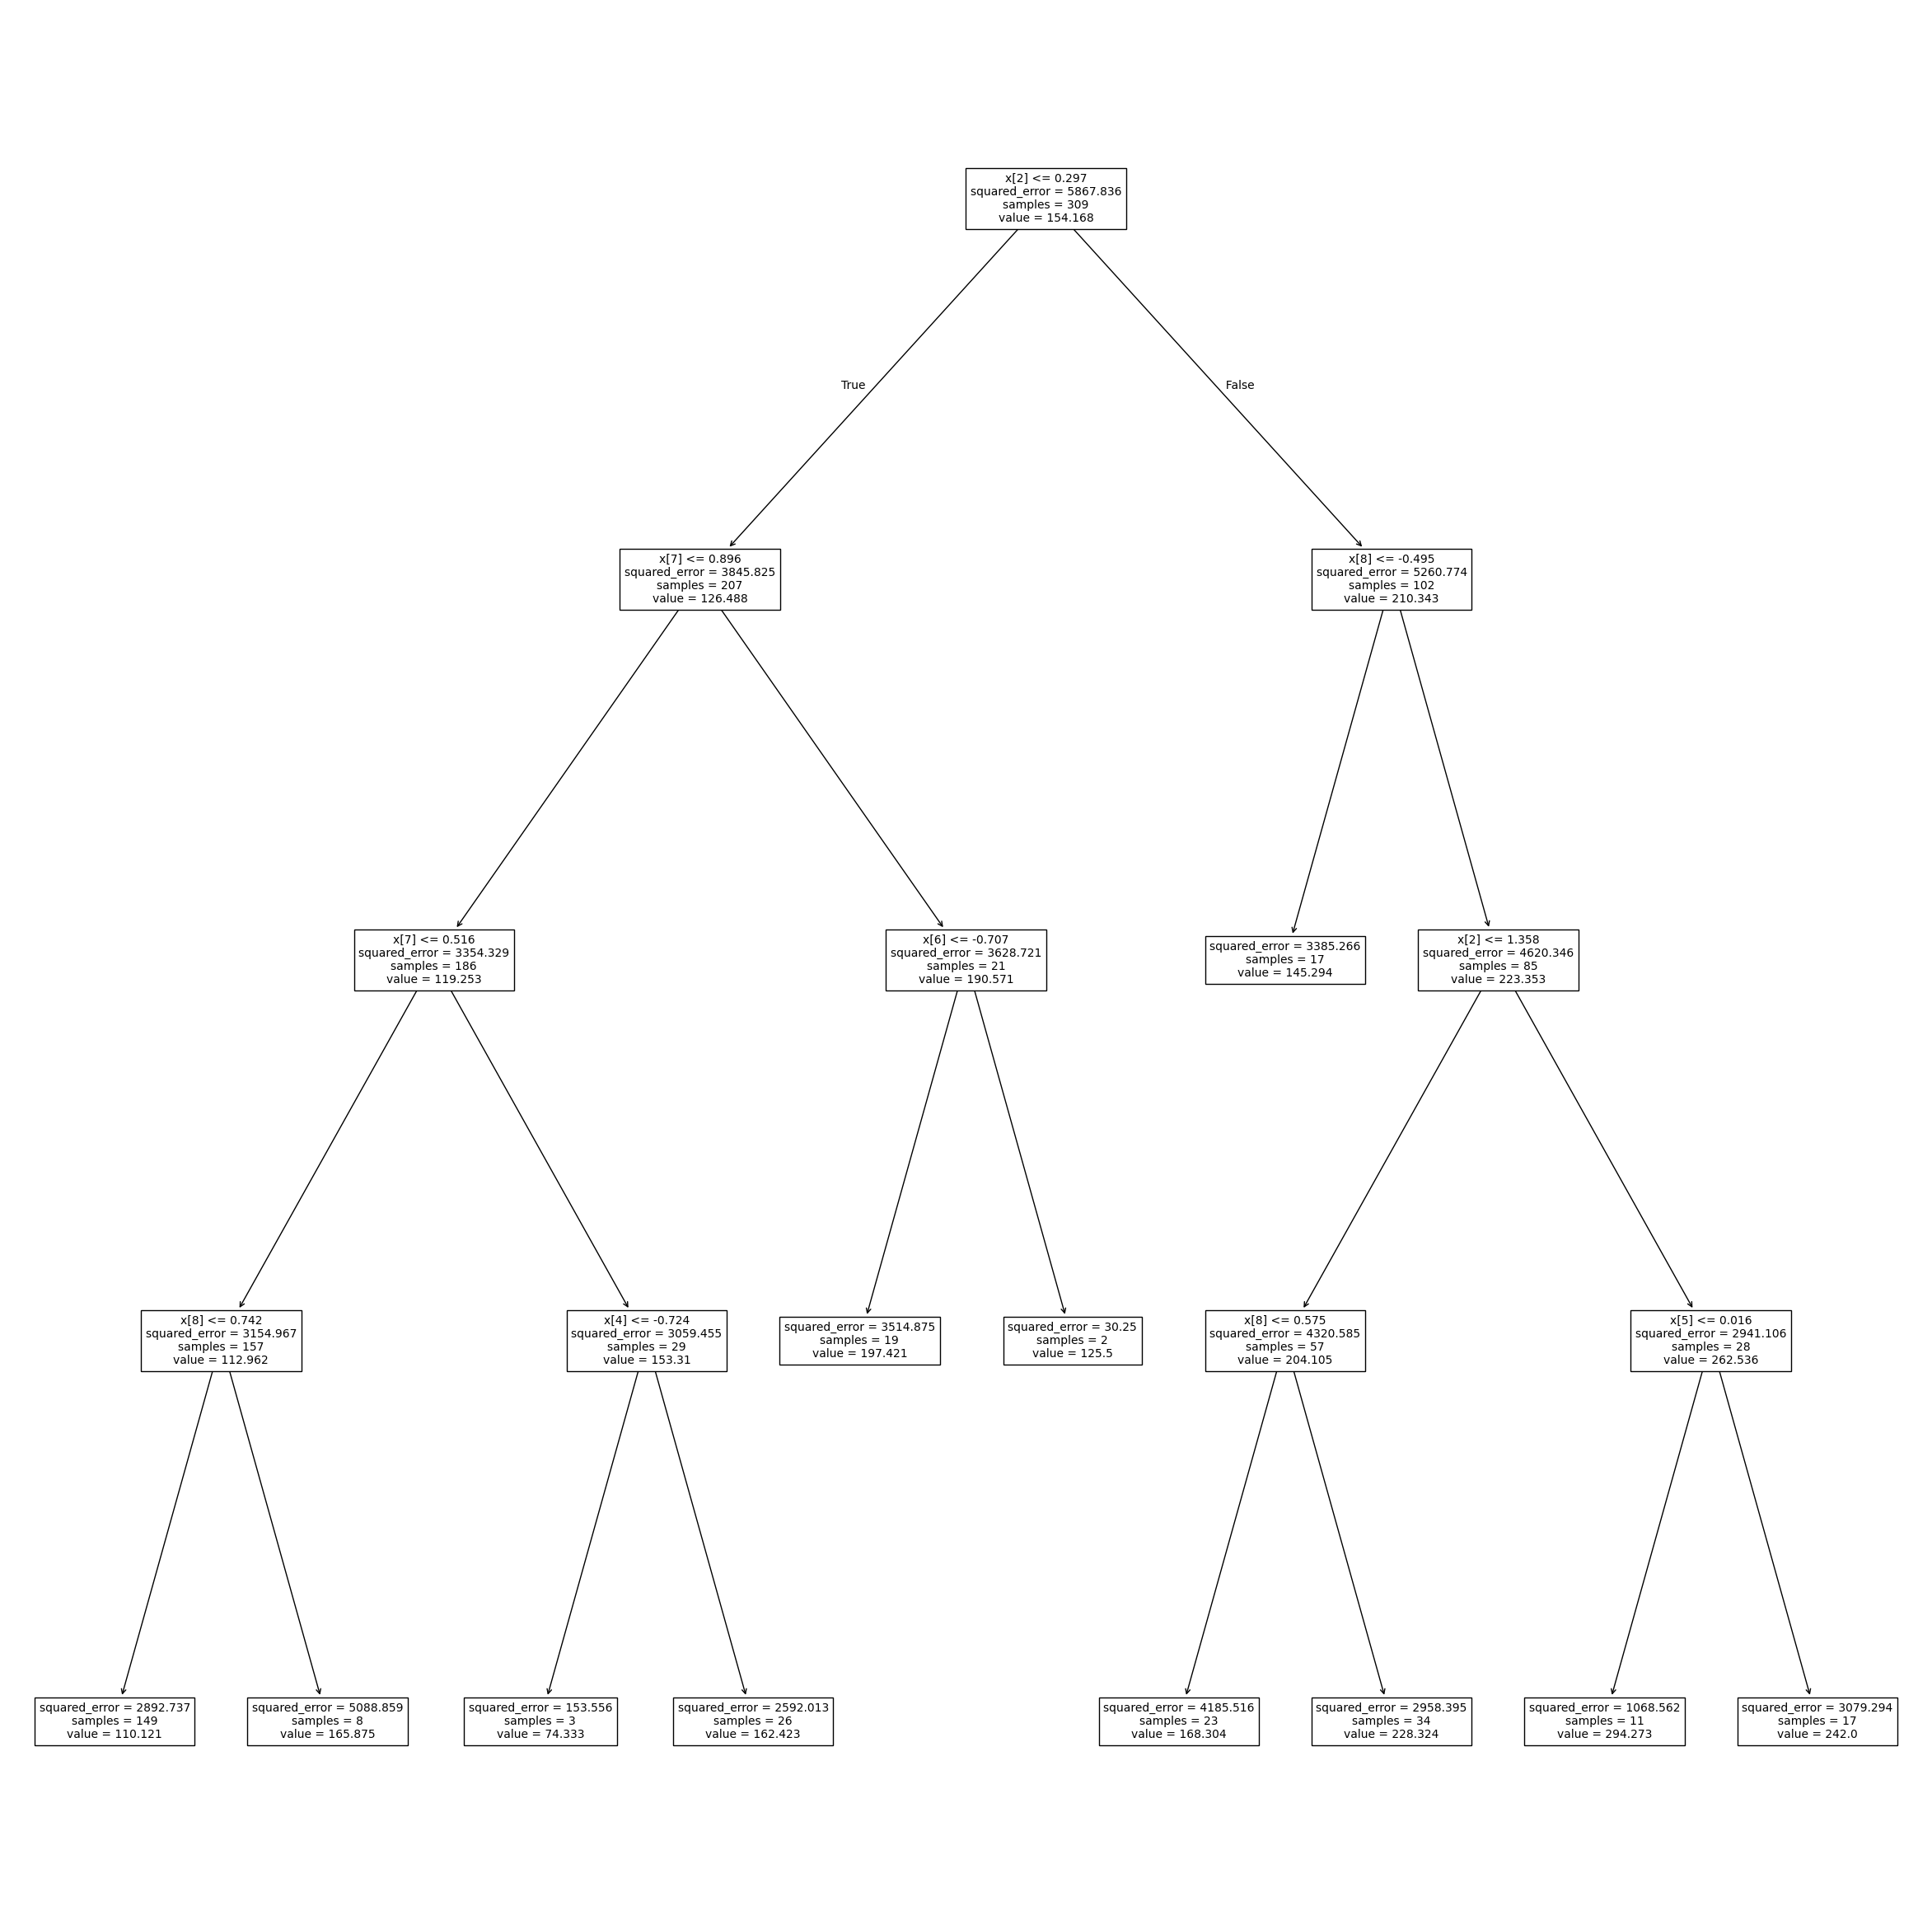

In [58]:
plt.figure(figsize=(30, 30))
print(plot_tree(grid.best_estimator_['model'], fontsize=10))

In [59]:
viz_model = dtreeviz.model(grid.best_estimator_['model'], X_train=X_train, y_train=y_train, feature_names=X_df.columns, target_name='breast_cancer', class_names=["0", "1"])

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

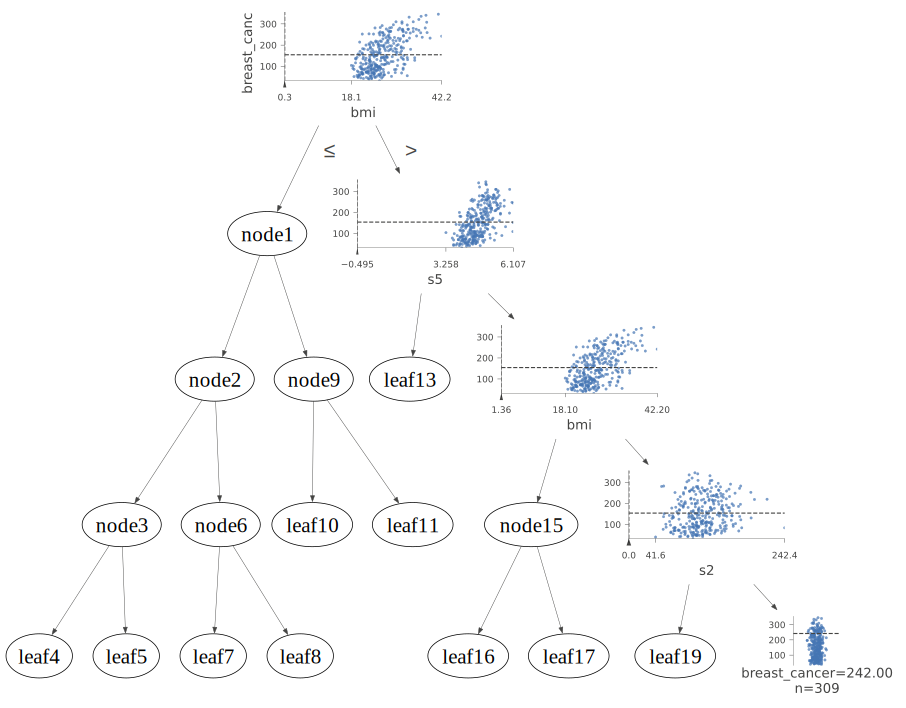

In [60]:
viz_model.view(scale=1.5, fontname='Arial')

In [61]:
print("Grid Cross val R2 on test: ", np.mean(cross_val_score(grid, y_test.reshape(-1, 1), y_pred.reshape(-1, 1), cv=5, scoring='r2')))

Grid Cross val R2 on test:  0.35030855580608583
